# I’m planning to use this in a video showing the exacerbation of wealth inequality in the United States.

In [3]:
from aegraph import AEGraph
import numpy as np
import pandas as pd

In [4]:
gini_csv = pd.read_csv("API_SI.POV.GINI_DS2_en_csv_v2_35.csv")

In [5]:
gini_csv

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,26.7,44.2,44.6,40.2,57.4,49.4,38.3,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264,Zambia,ZMB,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,51.5,NaN,NaN,NaN


In [6]:
countries = gini_csv["Country Name"]

In [7]:
gini_csv.loc[
    gini_csv.isna().sum(axis=1)
    .sort_values(ascending=True)
    .head(10)
    .index
].iloc[:,0]

251     United States
81     United Kingdom
35             Canada
29             Brazil
144        Luxembourg
48         Costa Rica
116             Italy
9           Argentina
190            Poland
77             France
Name: Country Name, dtype: object

In [8]:
import matplotlib.pyplot as plt

In [9]:
america_stats = gini_csv[gini_csv["Country Name"] == "United States"]
america_stats = america_stats.iloc[:, 4:].dropna(axis=1)
us_data = america_stats.iloc[0].astype(float).dropna()
us_years = us_data.index.astype(float)

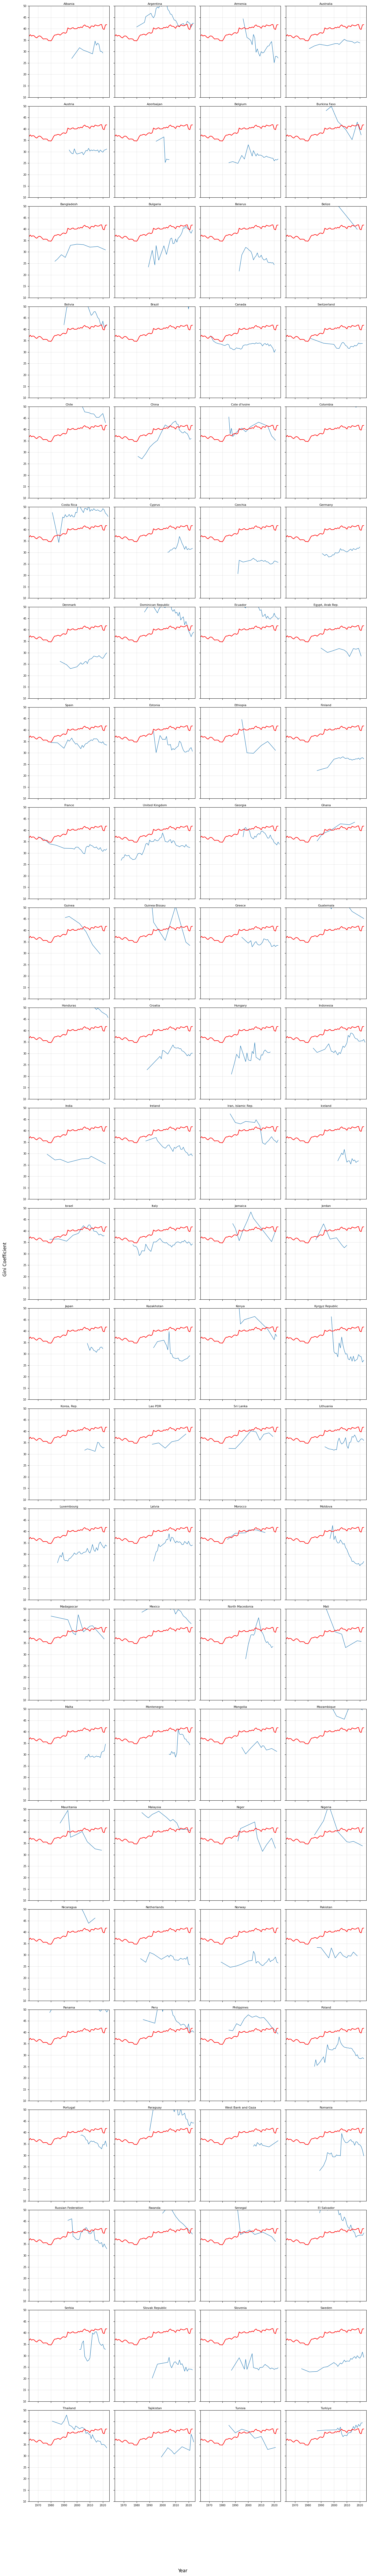

In [10]:
countries_mean_gini = {}

fig, axs = plt.subplots(
    25, 4,
    figsize=(14, 100),
    sharex=True,
    sharey=True
)

axs = axs.flatten()  # indexing

ax_idx = 0

for country in gini_csv["Country Name"]:
    if ax_idx >= 100:
        break

    country_df = gini_csv[gini_csv["Country Name"] == country]
    country_df = country_df.iloc[:, 4:].dropna(axis=1)

    data = country_df.iloc[0].astype(float).dropna()
    years = data.index.astype(float)

    # Only plot countries with sufficient data
    if len(data) > 5:
        ax = axs[ax_idx]

        ax.plot(years, data, linewidth=1)
        ax.plot(us_years, us_data, "-", color = "red")
        ax.set_title(country, fontsize=8, pad=3)

        ax.set_xlim(1963, 2025)
        ax.set_ylim(10, 50)

        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

        ax_idx += 1  # advance subplot ONLY when used
        
        countries_mean_gini[country] = np.mean(data)

# Turn off remaining unused axes
for ax in axs[ax_idx:]:
    ax.axis("off")

# Global labels
fig.supxlabel("Year", fontsize=12)
fig.supylabel("Gini Coefficient", fontsize=12)

plt.tight_layout(rect=[0.04, 0.03, 1, 0.97])
plt.show()


In [11]:
country_gini_slopes = {}

valid_years = np.arange(2000,2024,1)
for country in gini_csv["Country Name"]:
    country_df = gini_csv[gini_csv["Country Name"] == country]
    country_df = country_df.iloc[:, 4:].dropna(axis=1)

    data = country_df.iloc[0].astype(float).dropna()
    years = data.index.astype(float)    

    
    if np.isin(valid_years, years).all():
        valid_years_data = country_df.loc[:, valid_years.astype(str)]
        a, b = np.polyfit(years,data,1)
        country_gini_slopes[country] = [a,b]

In [12]:
df = pd.DataFrame(country_gini_slopes).T
df.sort_values(by=0, ascending=False)

,0,1
Romania,0.260456,-490.180668
Indonesia,0.188859,-345.385693
Luxembourg,0.179453,-328.855466
Lithuania,0.169718,-306.069670
Sweden,0.160690,-295.149126
United States,0.113966,-188.354220
Costa Rica,0.103086,-159.235782
Poland,0.046303,-61.438376
France,-0.067321,167.310010
Uruguay,-0.095361,233.772617


In [13]:
countries_mean_gini = {}

for country in gini_csv["Country Name"]:

    country_df = gini_csv[gini_csv["Country Name"] == country]
    country_df = country_df.iloc[:, 4:].dropna(axis=1)

    data = country_df.iloc[0].astype(float).dropna()
    years = data.index.astype(float)

    # Only plot countries with sufficient data
    if len(data) > 5:
        countries_mean_gini[country] = np.mean(data)

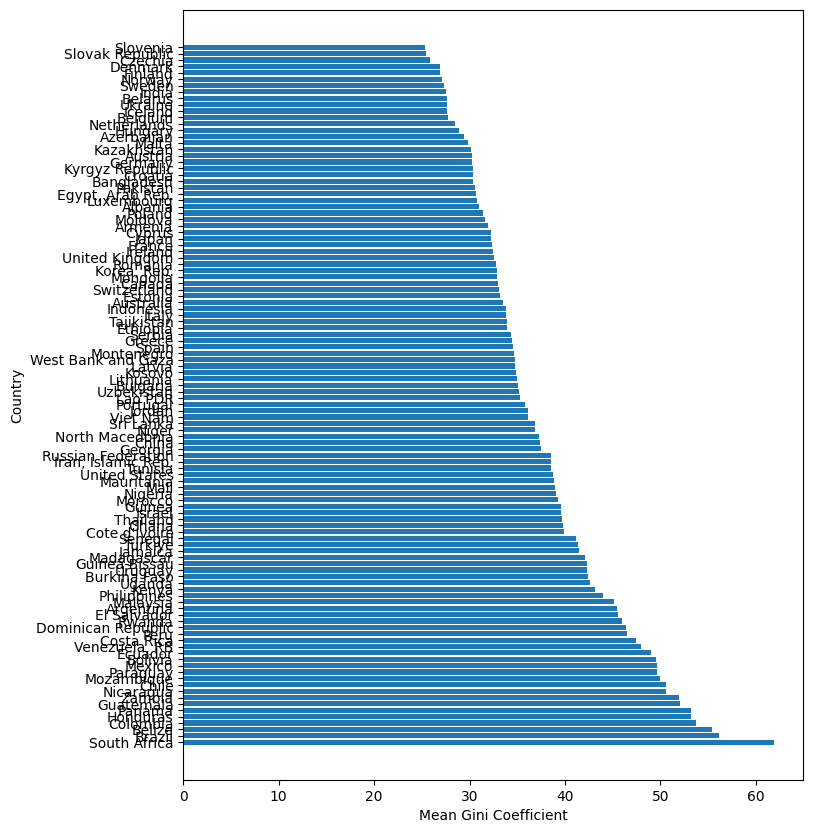

In [14]:
s = pd.Series(countries_mean_gini).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(s.index, s.values)
plt.xlabel("Mean Gini Coefficient")
plt.ylabel("Country")
plt.show()


In [15]:


names = countries_mean_gini.keys()
values = countries_mean_gini.values()

for idx, name in enumerate(names):
    print

In [16]:
countries_to_graph = ["United States","United Kingdom", "Canada", "France", "Germany", "Italy", "Poland", "Switzerland", "Sweden"]

In [17]:
colors = ["red","p_blue","p_purple","p_green","p_cyan", "p_orange", "p_gold", "p_pink", "p_brown"]

In [18]:
US_data = gini_csv[gini_csv["Country Name"] == "United States"].iloc[:,7:-2].T
US_data.index = US_data.index.astype(float)

In [19]:
US_data.index

Index([1963.0, 1964.0, 1965.0, 1966.0, 1967.0, 1968.0, 1969.0, 1970.0, 1971.0,
       1972.0, 1973.0, 1974.0, 1975.0, 1976.0, 1977.0, 1978.0, 1979.0, 1980.0,
       1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0,
       1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0,
       1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0,
       2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0,
       2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0],
      dtype='float64')

In [20]:
us_data_list = list(US_data[251])

In [21]:
from aegraph import COLOR_NAMES
from random import choice

In [22]:
gini = (
    AEGraph(width=960, height=960, compwidth=1080, compheight=1920,
            drop_shadow=True, cinematic_effects=True, comp_name="US Gini", fps=60)
    .grid()
    .set_xlabel("Year")
    .set_ylabel("Gini Index")
    .set_title("United States Gini Over Time")
    .grid(show=True, color="gray", alpha=0.3)
    .add_legend()
)


for idx, i in enumerate(countries_to_graph):
    country_df = gini_csv[gini_csv["Country Name"] == i]
    country_df = country_df.iloc[:,4:].dropna(axis=1)
    index = country_df.T.index.astype(float)
    data = (
        country_df
        .iloc[0]
        .astype(float)      # ensure numeric
        .dropna()           # remove missing years
    )
    gini.plot(
        index, 
        data, 
        animate = 5, 
        drop_shadow = False,
        color = colors[idx],
        label = i,
        )
gini.set_xlim(1963,2030).set_ylim(10,50).set_xticks().set_yticks()
gini.save()
gini.render()

JSX script saved to ./AEGraph_2026-03-17_23-00-54.jsx
JSX script saved to ./AEGraph_2026-03-17_23-00-54.jsx
[AEGraph] Attempting to run JSX script: /Users/reed/aegraph/aegraph/AEGraph_2026-03-17_23-00-54.jsx
[AEGraph] AppleScript command:

        tell application "Adobe After Effects 2025"
            activate
            DoScriptFile "/Users/reed/aegraph/aegraph/AEGraph_2026-03-17_23-00-54.jsx"
        end tell
        
[AEGraph] Script sent to After Effects: AEGraph_2026-03-17_23-00-54.jsx
